KulingNet - Cloud Image Classifier
- Based on: CCSN dataset, contains 2543 cloud images. 
- According to the World Meterological Organization’s genera-based classification recommendation, we divide into 11 different categories：

Ci = cirrus; 
Cs = cirrostratus; 
Cc = cirrocumulus; 
Ac = altocumulus; 
As = altostratus; 
Cu = cumulus; 
Cb = cumulonimbus; 
Ns = nimbostratus; 
Sc = stratocumulus; 
St = stratus; 
Ct = contrail.


All images are fixed resolution 256×256 pixels with the JPEG format.

-----------------------------------------------------------------------


In [ ]:
# General Imports 
import numpy as np
# import pandas as pd
import os 
from pathlib import Path 
import random

# For image processing
from PIL import Image
from IPython.display import Image as showIMG

# Pytorch 
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
# from torch.utils.data import DataLoader

# Torchvision
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision import models
from torchmetrics import Precision, Recall

# Plotting
import matplotlib.pyplot as plt

# Sklearn
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [6]:
# Where we are right now, absolute pathing  
base_dir = os.path.abspath('')
images_file_path = os.path.join(base_dir, "CCSN_Image_set")
# example path for cirrus clouds
ci_file_path = os.path.join(images_file_path, "Ci")

print(f"Example (Cirrus) filepath: {ci_file_path}")
print(f"Root filepath: {images_file_path}")

pathData = Path(images_file_path)

Example (Cirrus) filepath: c:\Users\Admin\Documents\Chalmers\Programmering\KulingNet\CCSN_Image_set\Ci
Root filepath: c:\Users\Admin\Documents\Chalmers\Programmering\KulingNet\CCSN_Image_set


In [7]:
# Overview of images
def walkDataset(dir_path):
    directories = []
    image_count = 0
    for dirpath, dirnames, filenames in os.walk(dir_path):
        directories.append(dirpath)
        image_count += len(filenames)
        print(f"There are {len(filenames)} " + "images in " + dirpath[73:])    
    print(f"Total image count: {image_count}")
    return directories

image_dir_paths = walkDataset(images_file_path)


There are 0 images in 
There are 221 images in Ac
There are 188 images in As
There are 242 images in Cb
There are 268 images in Cc
There are 139 images in Ci
There are 287 images in Cs
There are 200 images in Ct
There are 182 images in Cu
There are 274 images in Ns
There are 340 images in Sc
There are 202 images in St
Total image count: 2543


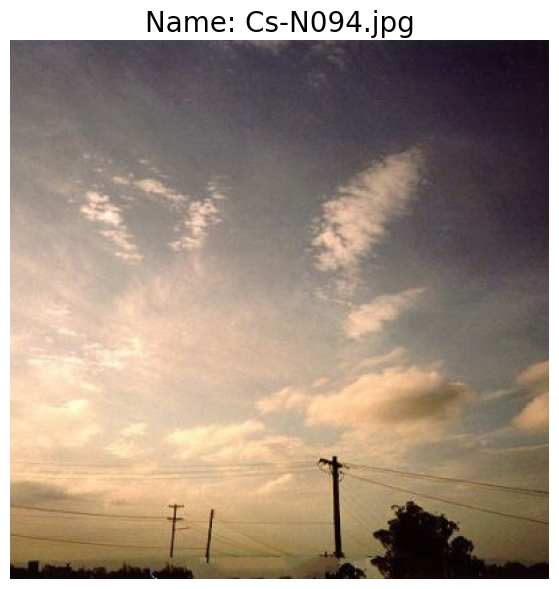

In [9]:
# Plot random image with class label

# Test path
# random_image_path = ci_file_path +  "\Ci-N001.jpg"
random.seed()

# Random image folder in directory
random_image_dir_path = random.choice(image_dir_paths)
# List of images in that folder
filenames = os.listdir(random_image_dir_path)
# Random image in the folder
random_image = random.choice(filenames)
# Absolute path to image 
random_image_path = os.path.join(random_image_dir_path, random_image)

def plotImage(imagePath_str):
    imagePath = Path(imagePath_str)
    #image_class = imagePath.stem
    img = Image.open(imagePath)
    # Access only the name
    img_name = imagePath_str[len(imagePath_str)-11:]

    # For plotting
    img_as_array = np.asarray(img)
    
    plt.figure(figsize=(10,7))
    plt.imshow(img_as_array)
    plt.title(f"Name: {img_name}", fontsize=20)
    plt.axis(False)

plotImage(random_image_path)

In [10]:
# Tensor ~ vector (array of components)
# Compose allows for list of several transformations simultanously 
transform = transforms.Compose([
    # to fit with current NN
    #transforms.Resize((32,32)),
    # Input images as 0-255 RGB-values, we want in range [-1,1]
    # Converts PIL [0,255] to [0.0, 1.0]
    transforms.ToTensor(),
    
    transforms.Resize((256,256)),
    
    # Adjusts with mean=0.5, stdv=0.5 
    # 3 Channels because of RGB (Greyscale would be 1 channel)
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),

    # Data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)
])

# Create the full dataset
full_dataset = datasets.ImageFolder(root=images_file_path, transform=transform)
# Example image size
full_dataset[0][0].size()

"""
# Create names
images = full_dataset.imgs
name_list = []
for file_name in images:
    file_name = file_name[0][len(file_name)-13:]
    file_name = file_name[:-4]
    name_list.append(file_name)

#name_list
"""

'\n# Create names\nimages = full_dataset.imgs\nname_list = []\nfor file_name in images:\n    file_name = file_name[0][len(file_name)-13:]\n    file_name = file_name[:-4]\n    name_list.append(file_name)\n\n#name_list\n'

In [11]:
# Labels
class_names = ["altocumulus", "altostratus", "cumulonimbus", "cirrocumulus", 
               "cirrus", "cirrostratus", "contrail", "cumulus", "nimbostratus", 
               "stratocumulus", "stratus"]


In [12]:
# Train, test split
train_data, test_data = torch.utils.data.random_split(full_dataset,[0.8,0.2])

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
# No shuffling since no training is done, randomness not needed
test_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=False, num_workers=2)

full_dataset.class_to_idx

{'Ac': 0,
 'As': 1,
 'Cb': 2,
 'Cc': 3,
 'Ci': 4,
 'Cs': 5,
 'Ct': 6,
 'Cu': 7,
 'Ns': 8,
 'Sc': 9,
 'St': 10}

torch.Size([3, 256, 256])
Cloud type: cumulonimbus, label: 2


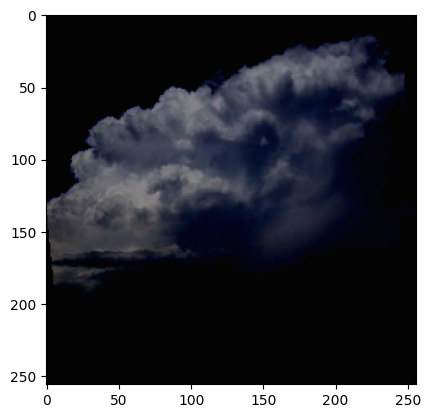

In [13]:
image, label = train_data[0]
# 3 channel 32x32 images
print(image.size())
# Print name???
print(f"Cloud type: {class_names[label]}, label: {label}")

image = image.squeeze().permute(1, 2, 0)

plt.imshow(image)
plt.show()

In [9]:
# TRANSFER LEARNING


In [20]:
showIMG("2D-CNN-layer-calculation.png")

class KulingNet(nn.Module):
    # Create base nn-architecture
    def __init__(self, num_classes=11):
        super().__init__()
        self.name = "KulingNet"  

        # 3x3 kernel moves across images, creates feature maps
        # Maxpool2d: Pools together 2x2 pixels to single pixel 
        # (extracts important features), out_channels double after each pooling
        self.features = nn.Sequential(
            # cl1
            nn.Conv2d(3, 32, kernel_size=5, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # cl2
            nn.Conv2d(32, 64, kernel_size=5, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # cl3
            nn.Conv2d(64, 128, kernel_size=5, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # cl4
            nn.Conv2d(128, 256, kernel_size=5, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        # Adaptive pooling for flexibility, determine output size regardless of input
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # "Dense" layers, neurons have to be compatible, but chosen freely
        self.fc = nn.Sequential(
            # fc1
            nn.Linear(256, 128),
            nn.ReLU(),
            # Reduce overfitting by "turning off" neurons randomly, rate depends on data size
            # this small <3000 images needs strong regularization (NOTE data aug also regularizes)
            nn.Dropout(0.4),

            # fc2
            nn.Linear(128, num_classes)
        )
        """
        # OLD fc2 
        nn.Linear(128, 84),
        nn.ReLU(),
        nn.Dropout(0.4),
        """
    
    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        #print(x.shape)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [21]:
net = KulingNet()
loss_function = nn.CrossEntropyLoss()
# lr: step size during gradient descent
# momentum: using past gradients (inertia)
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum=0.9)

In [16]:
# Training on CCSN
def train_on_CCSN():
    for epoch in range(50):
        print("Training epoch:", epoch+1, "...")
        running_loss = 0.0
        for i, data in enumerate(train_loader):
            # each batch contains data
            inputs, labels = data

            optimizer.zero_grad()

            outputs = net(inputs)
            # Calculate difference of predicted vs actual labels
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        print(f"Running loss: {running_loss / len(train_loader):.4f}")

#train_on_CCSN()

In [22]:
# Save net parameters
saved_net_dir = base_dir + "\\Trained_models"
print(saved_net_dir)
#torch.save(net.state_dict(), saved_net_dir + "\\KulingNet2.0_trained.pth")

c:\Users\Admin\Documents\Chalmers\Programmering\KulingNet\Trained_models


In [23]:
# Load net with parameters
net = KulingNet()
net.load_state_dict(torch.load(saved_net_dir + "\\KulingNet2.0_trained.pth"))

<All keys matched successfully>

In [ ]:
# Checking the network
correct = 0
total = 0 

precision = Precision(task="multiclass", num_classes=11, average="weighted")
recall = Recall(task="multiclass", num_classes=11, average="weighted")

# Metrics for evaluation
y_true = []
y_pred = []

net.eval()
# no gradient descent during evaluation, just feed input forward
with torch.no_grad():
    for images, labels in test_loader:
        # feed test through net
        outputs = net(images)
        
        # find prediction (highest probability)
        _ , predicted = torch.max(outputs, 1)
        total += labels.size(0)

        # For confusion matrix
        y_true.extend(labels)
        y_pred.extend(predicted)

        # Compute metrics
        precision(predicted,labels)
        recall(predicted,labels)
        correct += (predicted == labels).sum().item()

# 
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute Precision, Recall & Accuracy metrics
prec_score = precision.compute()
rec_score = recall.compute()
accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.3f} %",
    f"Precision Score: {prec_score:.3f}",
    f"Recall Score: {rec_score:.3f}",
    sep="\n"
)

"""
Latest metrics: 
Accuracy: 41.916 %
Precision Score: 0.418
Recall Score: 0.419
"""

Accuracy: 41.916 %
Precision Score: 0.418
Recall Score: 0.419


'\nLatest metrics: \nAccuracy: 42.604 %\nPrecision Score: 0.414\nRecall Score: 0.426\n'

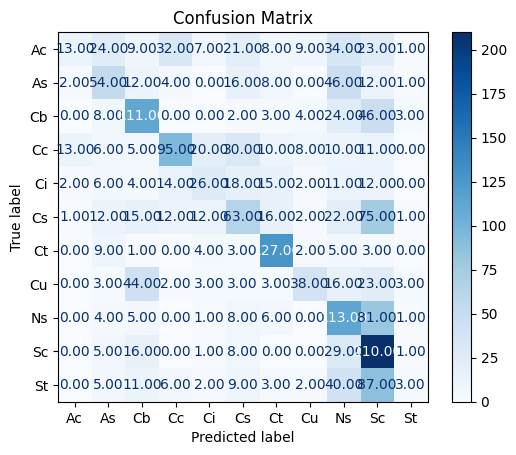

In [27]:
# Confusion Matrix & Classification report
def get_confusion_matrix(y_true, y_pred):
    # 11 Unique output classes
    labels = [x for x in range(11)]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    display_labels = list(full_dataset.class_to_idx.keys())
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues, values_format=".2f")
    plt.title("Confusion Matrix")
    plt.show()

    return cm

cm = get_confusion_matrix(y_true, y_pred)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Pred: nimbostratus, Label: ?


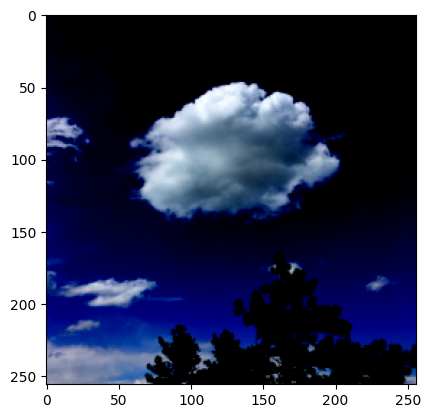

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Pred: nimbostratus, Label: ?


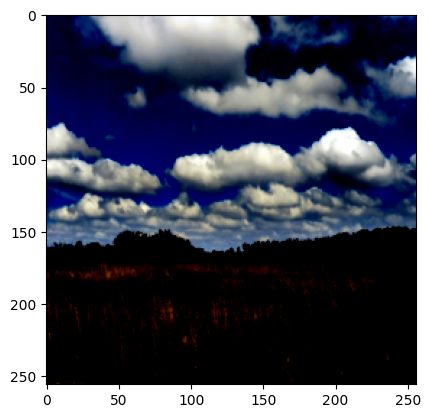

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Pred: cumulus, Label: ?


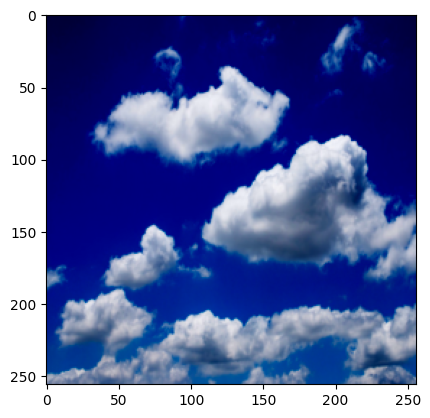

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Pred: cumulonimbus, Label: ?


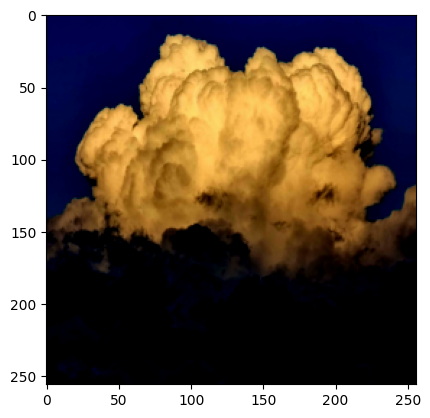

In [64]:
# Transform test images with different format 
new_transform = transforms.Compose([
    #transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
    transforms.Resize((256,256)),
])

# Helper function
def load_image(path):
    image = Image.open(path)
    image = new_transform(image)
    # Add batch dimension
    image = image.unsqueeze(0)
    return image

# Pathing
test_images_file_path = os.path.join(base_dir, "Testing_Images")
test_images_list = os.listdir(test_images_file_path)

# Visual 
img = Image.open(test_images_file_path + '\\Cu_1.jpg')
#plt.imshow(img)
#plt.show()

# Images as tensors, only Cumulus
images = [load_image(test_images_file_path + "\\" + img) for img in test_images_list]

def test_example_images():
    # Set to evaluation mode
    net.eval()
    # No gradient descent, as no training occurs
    with torch.no_grad():
        for image in images:
            output = net(image)
            _, predicted = torch.max(output,1)
            print(f"Pred: {class_names[predicted.item()]}, Label: ?")
            image = image.squeeze().permute(1, 2, 0)
            plt.imshow(image)
            plt.show()

test_example_images()
# fc1: 115200*120
